In [1]:
import json
import re
from pathlib import Path
from collections import defaultdict, Counter
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import numpy as np
from itertools import combinations

# ── config ────────────────────────────────────────────
OUTPUT_FOLDER = Path(r"C:\Users\ensi\Desktop\python ai\final_data_cleaned")
CATEGORIES    = ["languages", "frontend", "backend", "databases", "devops_cloud", "ai_ml", "tools"]

# ── load all files ────────────────────────────────────
records = []
for fp in OUTPUT_FOLDER.glob("*.json"):
    data = json.loads(fp.read_text(encoding="utf-8"))
    records.append(data)

df = pd.DataFrame(records)
print(f"Loaded {len(df)} job records")

Loaded 2403 job records


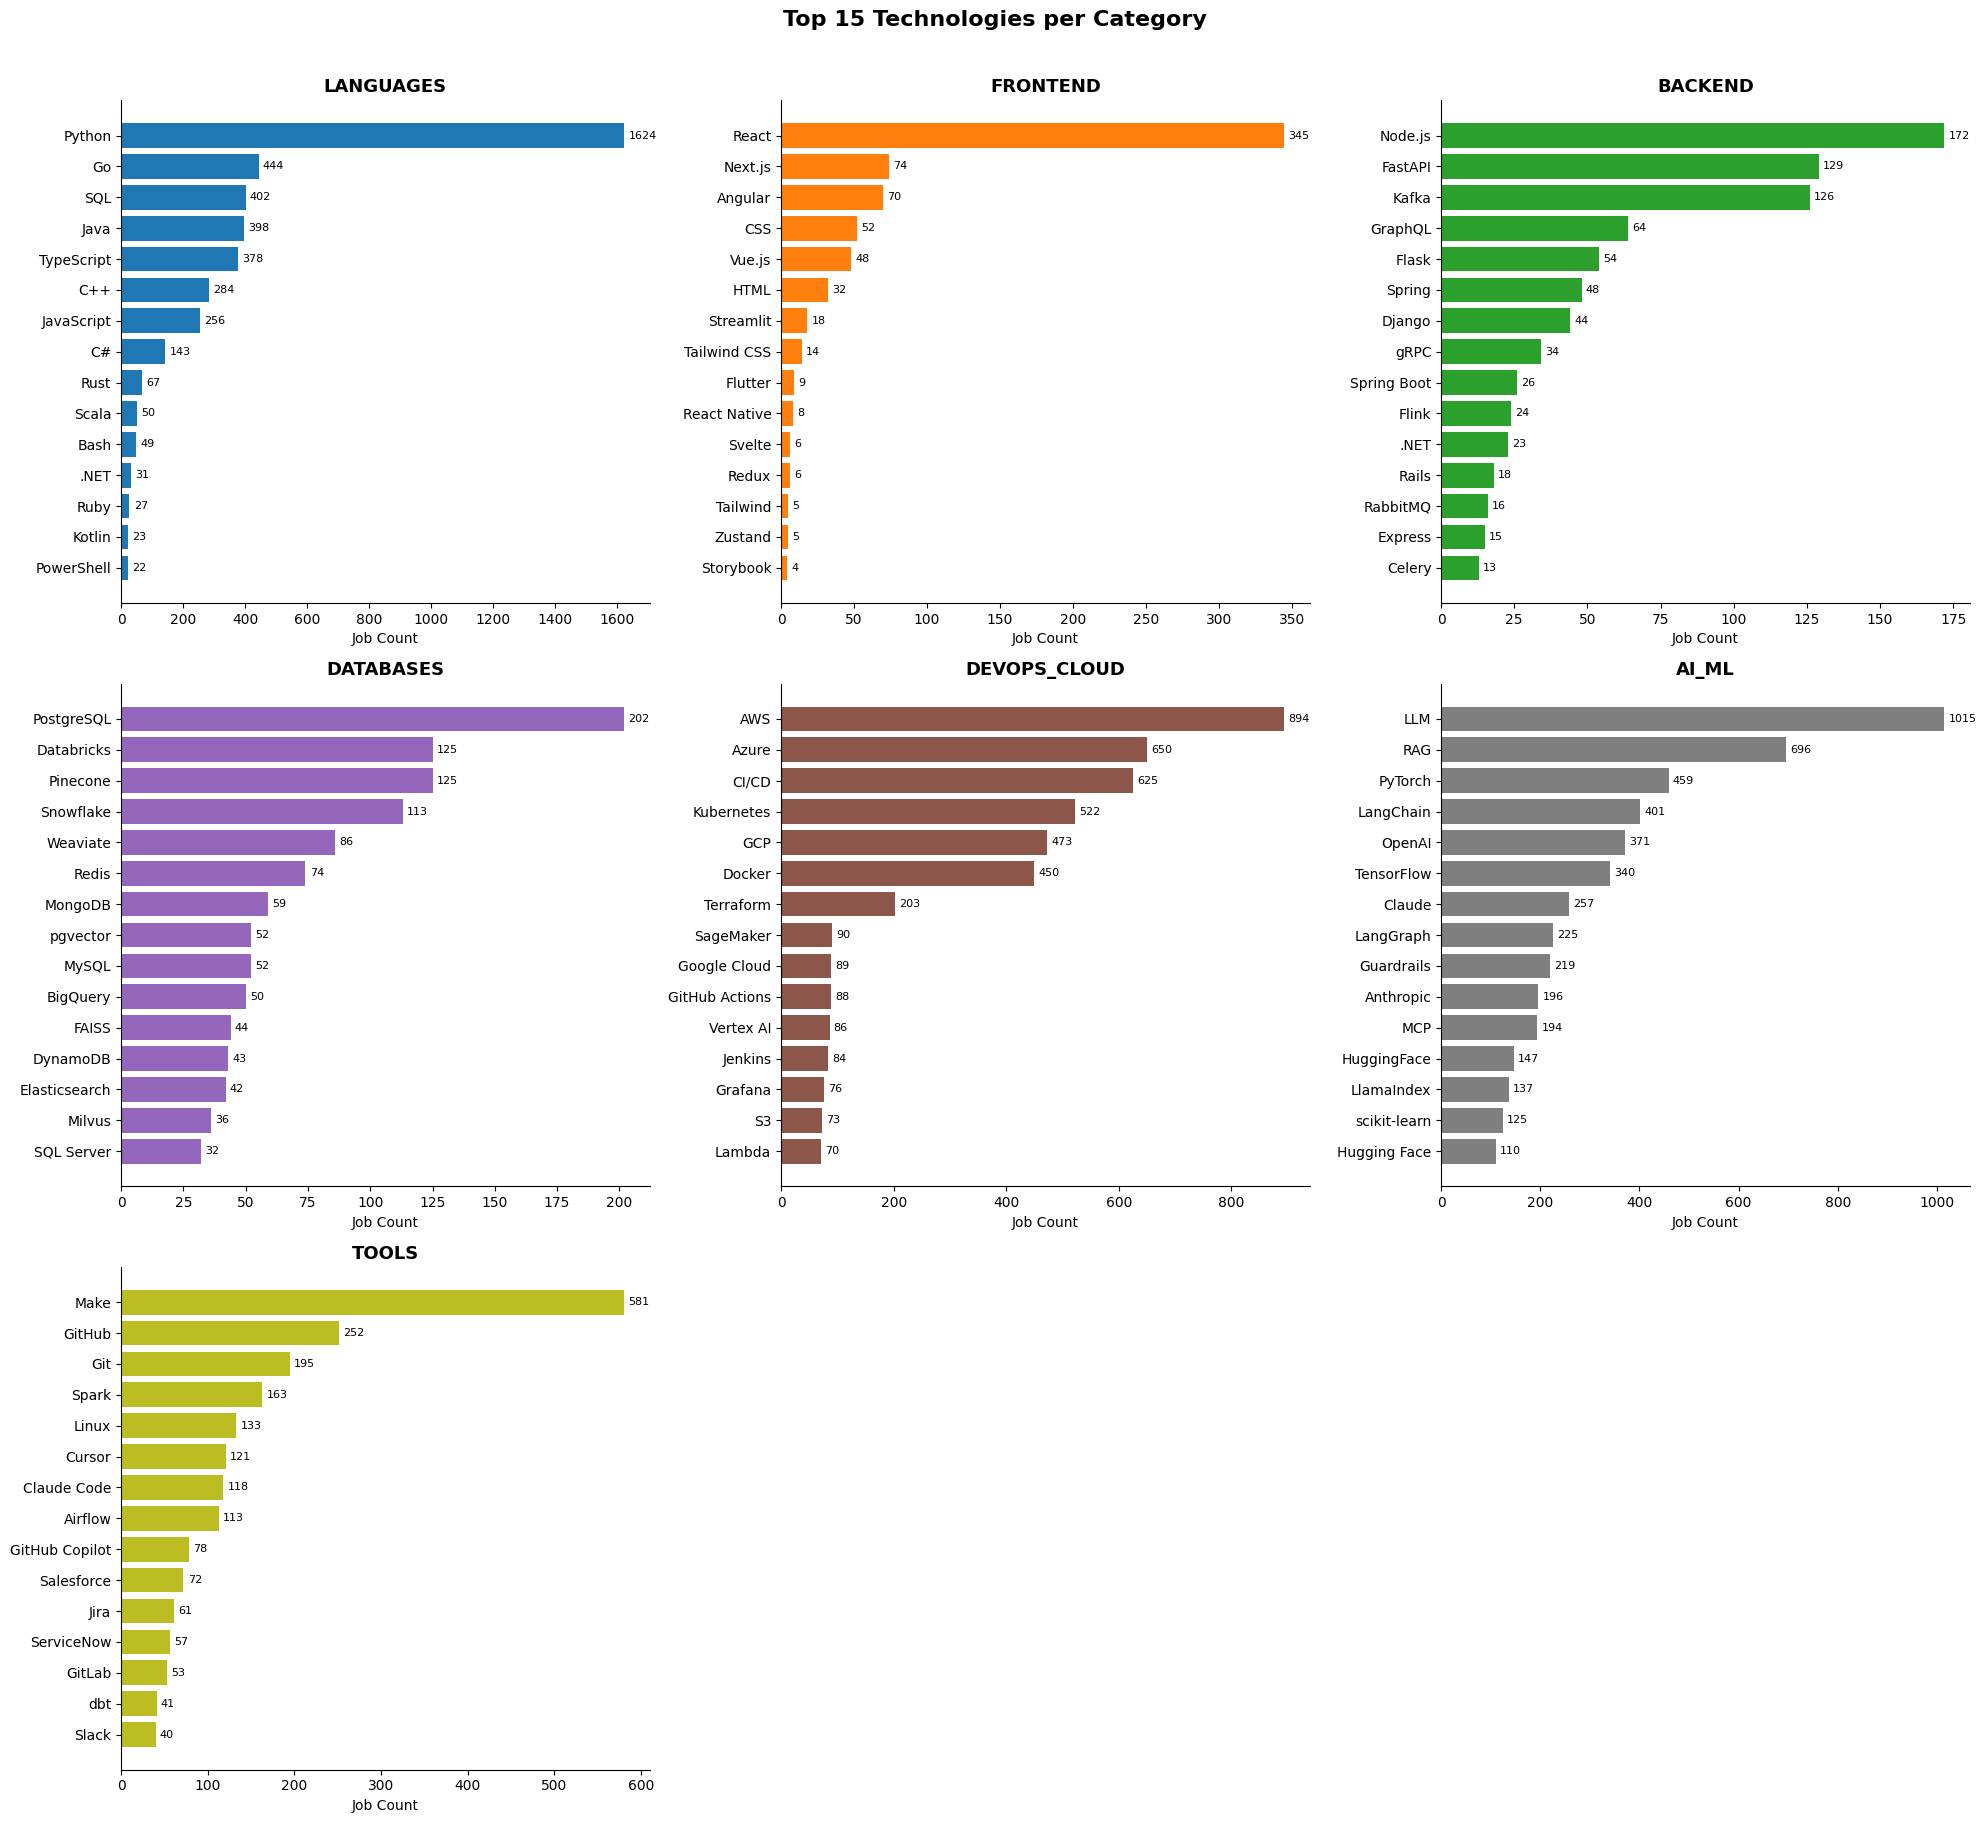

✅ Plot 1 saved


In [2]:
# ── 1. TECH FREQUENCY — top 15 per category ──────────
from collections import Counter

fig, axes = plt.subplots(3, 3, figsize=(20, 18))
axes = axes.flatten()

for idx, cat in enumerate(CATEGORIES):
    counter = Counter()
    for rec in records:
        for term in rec.get(cat, []):
            if term and term.strip():
                counter[term.strip()] += 1

    top15 = counter.most_common(15)
    if not top15:
        continue

    terms  = [t[0] for t in top15][::-1]
    counts = [t[1] for t in top15][::-1]

    ax = axes[idx]
    bars = ax.barh(terms, counts, color=cm.tab10(idx / len(CATEGORIES)))
    ax.set_title(f"{cat.upper()}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Job Count")
    ax.bar_label(bars, padding=3, fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

# hide unused subplot
for j in range(len(CATEGORIES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Top 15 Technologies per Category", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("01_tech_frequency.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot 1 saved")

C:\Users\ensi\AppData\Local\Temp\ipykernel_21940\2102255877.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=25, ha="right")


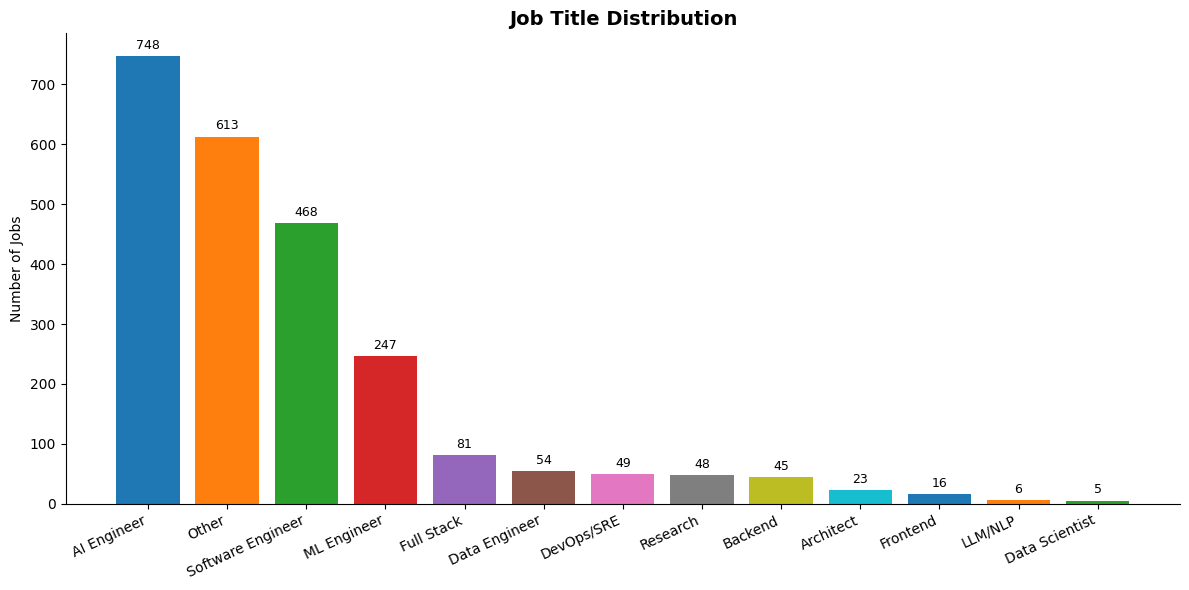

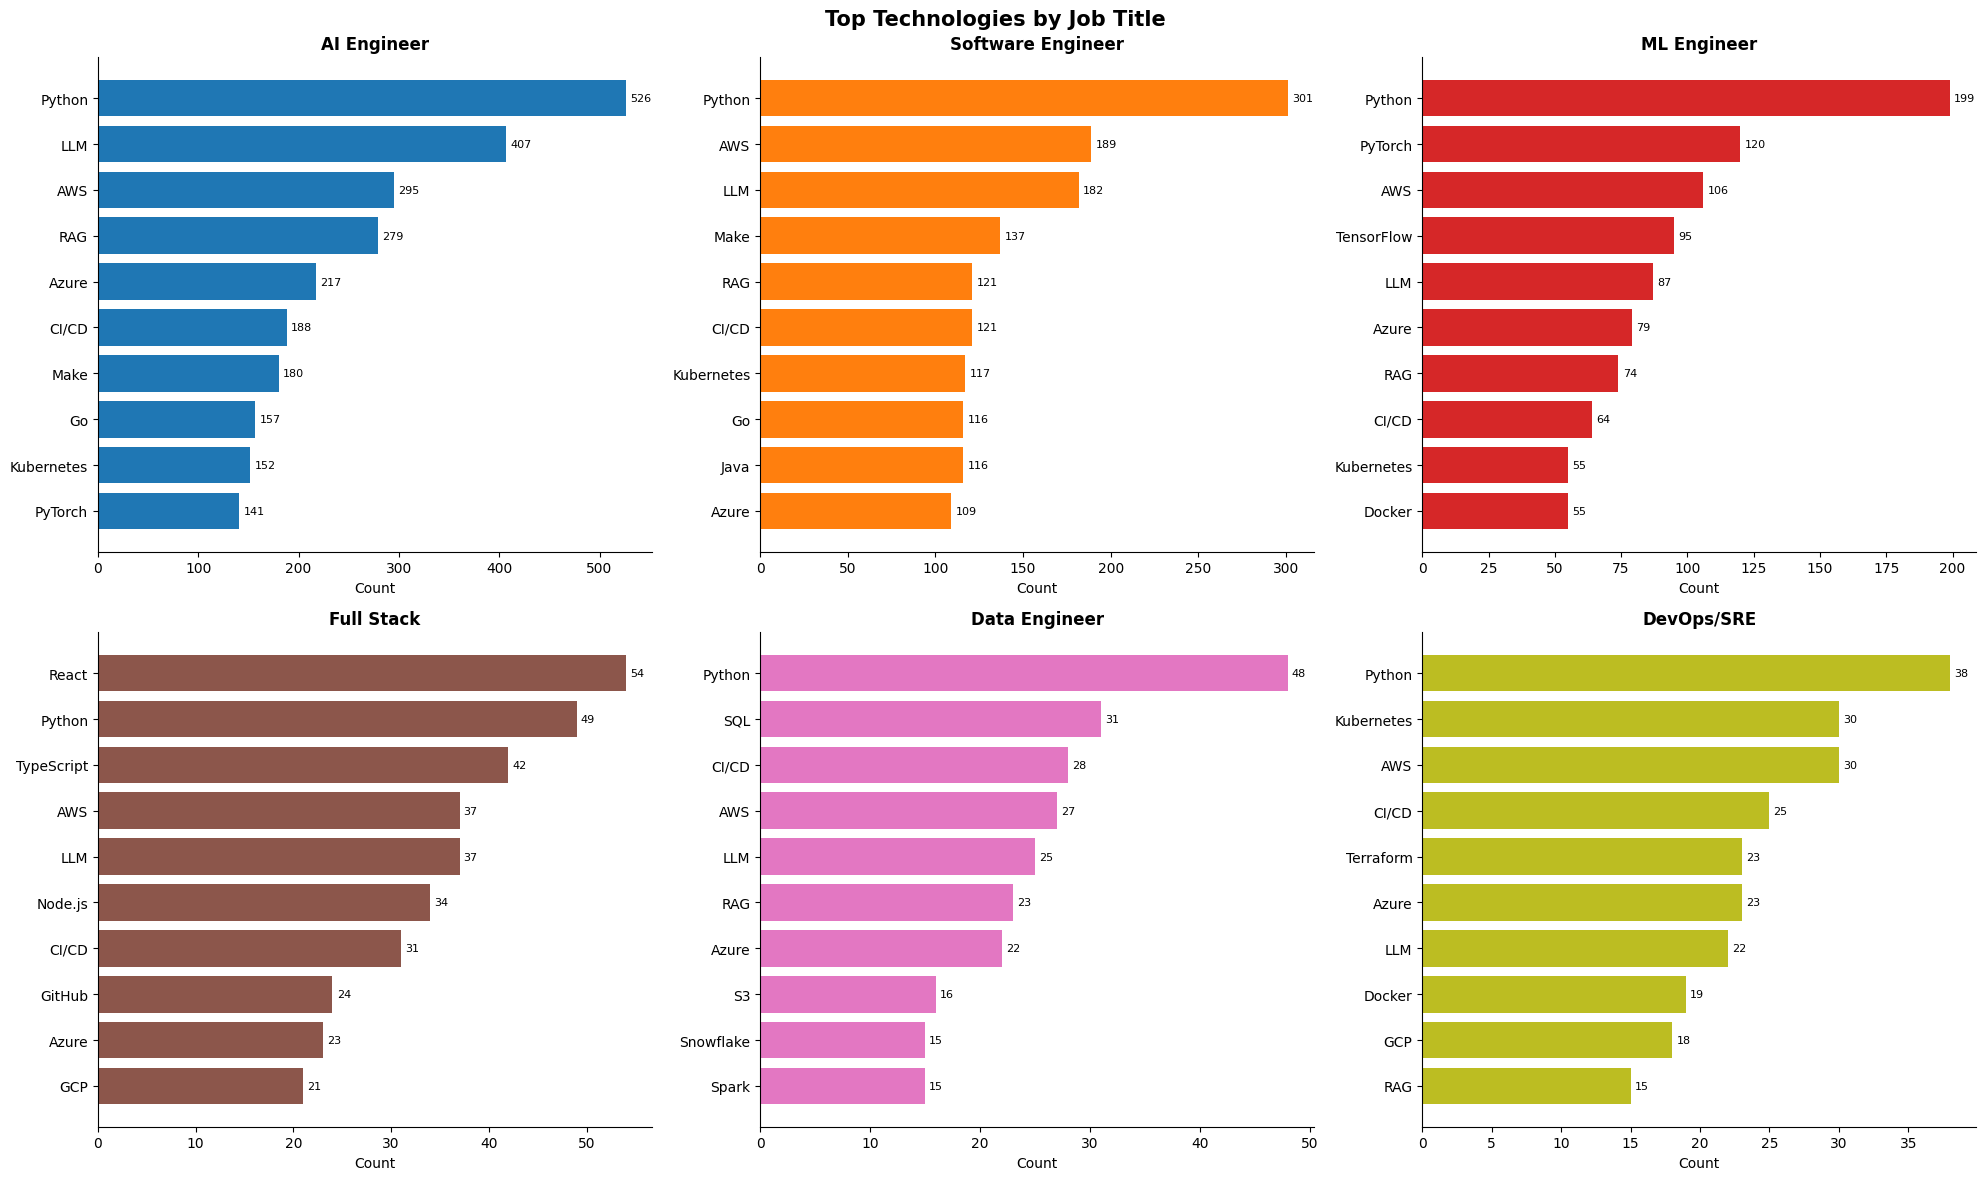

✅ Plot 2 saved


In [3]:
# ── 2. JOB TITLE ANALYSIS ─────────────────────────────
# clean and bucket job titles
def bucket_title(title: str) -> str:
    t = str(title).lower()
    if any(x in t for x in ["ml engineer", "machine learning"]):        return "ML Engineer"
    if any(x in t for x in ["ai engineer", "ai/ml", "ai ml"]):          return "AI Engineer"
    if any(x in t for x in ["data scientist"]):                          return "Data Scientist"
    if any(x in t for x in ["data engineer"]):                           return "Data Engineer"
    if any(x in t for x in ["full stack", "fullstack"]):                 return "Full Stack"
    if any(x in t for x in ["frontend", "front end", "front-end"]):      return "Frontend"
    if any(x in t for x in ["backend", "back end", "back-end"]):         return "Backend"
    if any(x in t for x in ["devops", "sre", "platform engineer"]):      return "DevOps/SRE"
    if any(x in t for x in ["software engineer", "software developer"]): return "Software Engineer"
    if any(x in t for x in ["llm", "nlp", "language model"]):            return "LLM/NLP"
    if any(x in t for x in ["research"]):                                 return "Research"
    if any(x in t for x in ["architect"]):                                return "Architect"
    return "Other"

for rec in records:
    rec["title_bucket"] = bucket_title(rec.get("job_title", ""))

# count buckets
bucket_counts = Counter(rec["title_bucket"] for rec in records)
buckets_sorted = sorted(bucket_counts.items(), key=lambda x: x[1], reverse=True)

# ── plot 2a: job title distribution ───────────────────
fig, ax = plt.subplots(figsize=(12, 6))
labels  = [b[0] for b in buckets_sorted]
values  = [b[1] for b in buckets_sorted]
colors  = cm.tab10.colors[:len(labels)]

bars = ax.bar(labels, values, color=colors)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title("Job Title Distribution", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Jobs")
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("02a_title_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# ── plot 2b: top tech per title bucket ────────────────
top_buckets = [b[0] for b in buckets_sorted if b[0] != "Other"][:6]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, bucket in enumerate(top_buckets):
    counter = Counter()
    for rec in records:
        if rec["title_bucket"] == bucket:
            for cat in CATEGORIES:
                for term in rec.get(cat, []):
                    if term:
                        counter[term] += 1

    top10 = counter.most_common(10)
    if not top10:
        continue

    terms  = [t[0] for t in top10][::-1]
    counts = [t[1] for t in top10][::-1]

    ax = axes[idx]
    bars = ax.barh(terms, counts, color=cm.tab10(idx / 6))
    ax.set_title(f"{bucket}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Count")
    ax.bar_label(bars, padding=3, fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Top Technologies by Job Title", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("02b_tech_by_title.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot 2 saved")

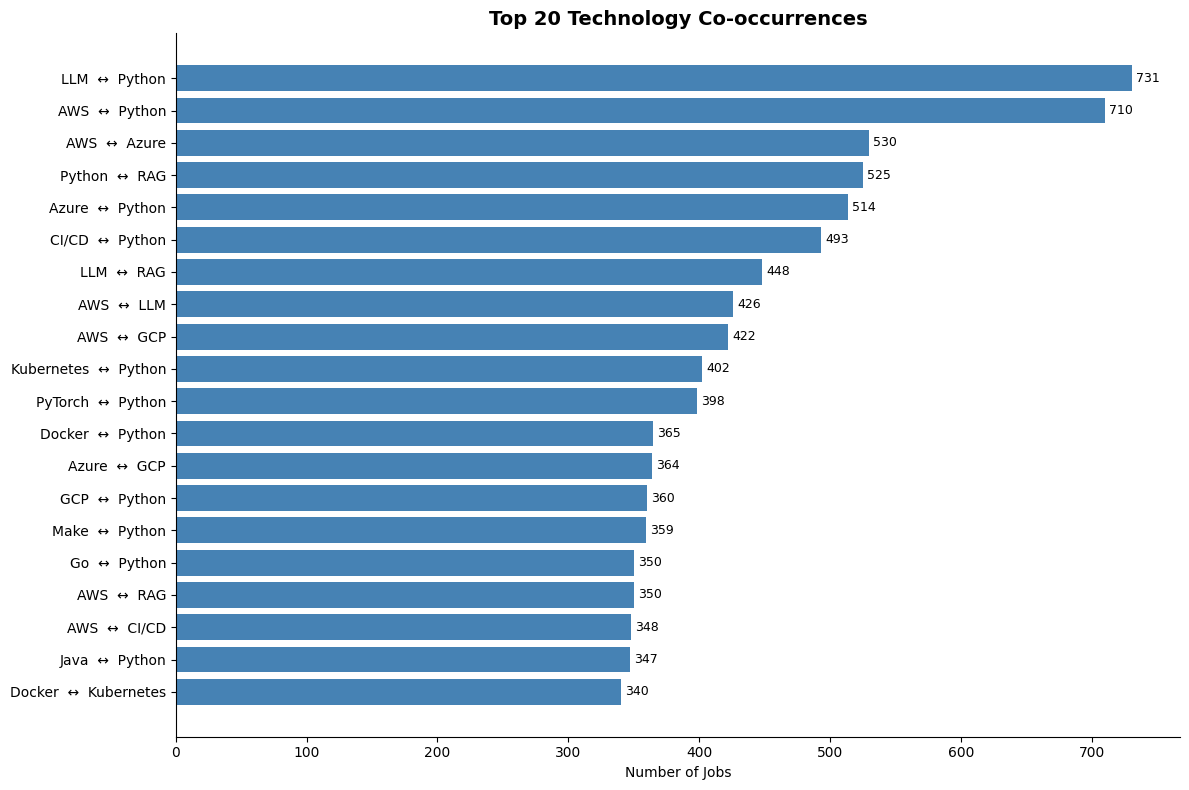

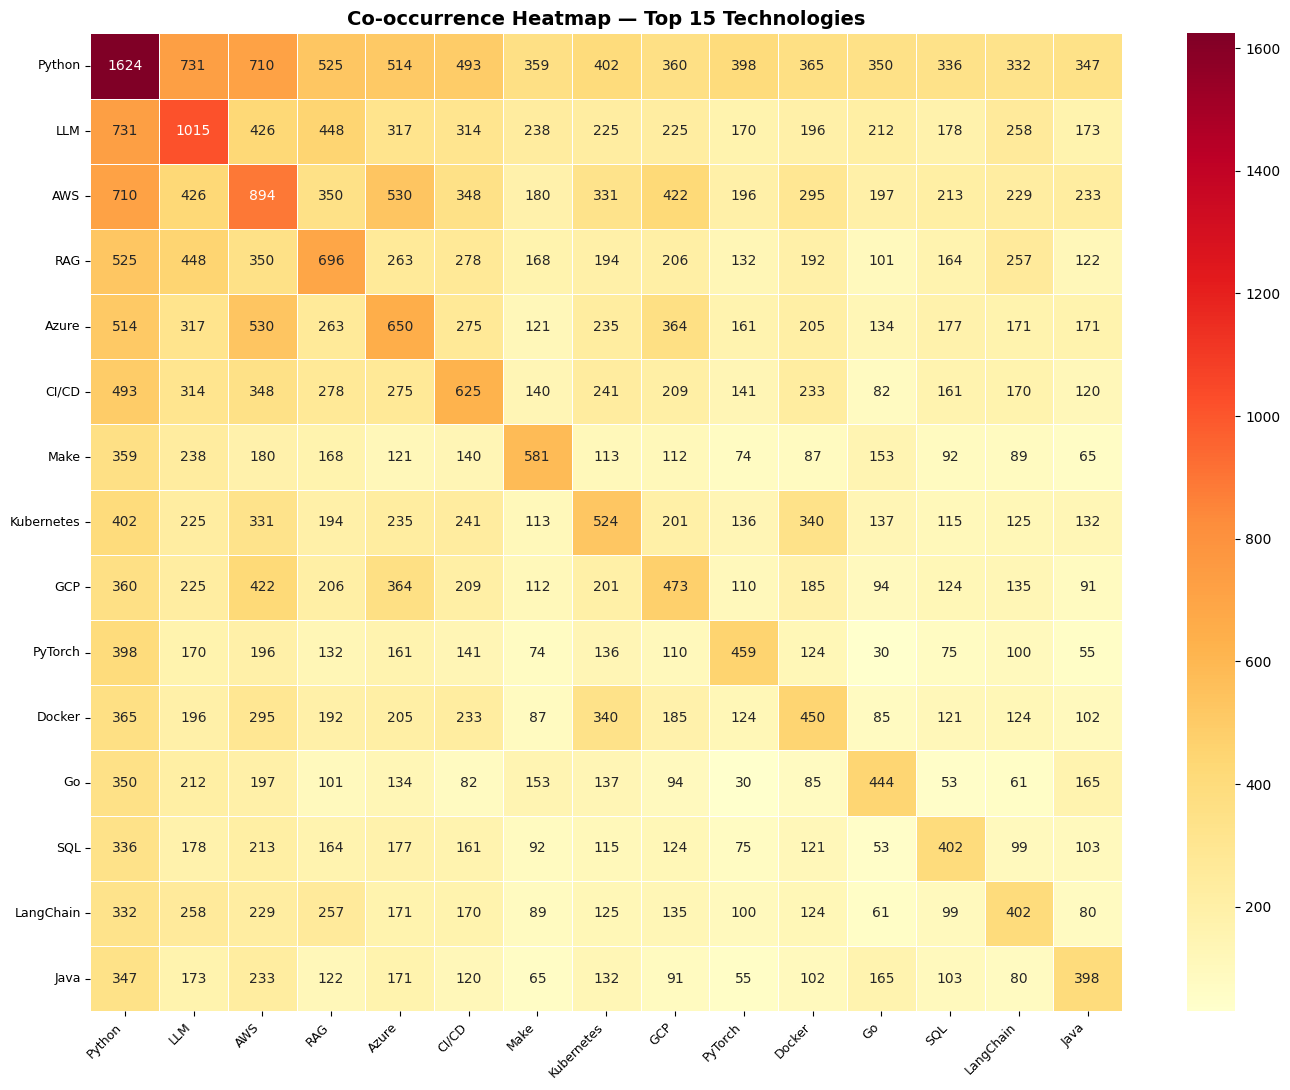

✅ Plot 3 saved


In [4]:
# ── 3. CO-OCCURRENCE — which techs appear together ────
from itertools import combinations
import numpy as np

# collect all terms per job
all_terms_per_job = []
for rec in records:
    terms = []
    for cat in CATEGORIES:
        for term in rec.get(cat, []):
            if term:
                terms.append(term.strip())
    all_terms_per_job.append(terms)

# count co-occurrences
cooccur = Counter()
for terms in all_terms_per_job:
    unique = list(set(terms))
    for a, b in combinations(sorted(unique), 2):
        cooccur[(a, b)] += 1

# top 20 pairs
top_pairs = cooccur.most_common(20)

# ── plot 3a: top co-occurring pairs ───────────────────
fig, ax = plt.subplots(figsize=(12, 8))
labels  = [f"{p[0][0]}  ↔  {p[0][1]}" for p in top_pairs][::-1]
values  = [p[1] for p in top_pairs][::-1]

bars = ax.barh(labels, values, color="steelblue")
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title("Top 20 Technology Co-occurrences", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Jobs")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("03a_cooccurrence_pairs.png", dpi=150, bbox_inches="tight")
plt.show()

# ── plot 3b: heatmap of top 15 terms ──────────────────
# get top 15 most frequent terms overall
global_counter = Counter()
for terms in all_terms_per_job:
    global_counter.update(set(terms))

top15_terms = [t[0] for t in global_counter.most_common(15)]

# build matrix
matrix = np.zeros((15, 15), dtype=int)
for i, t1 in enumerate(top15_terms):
    for j, t2 in enumerate(top15_terms):
        if i == j:
            matrix[i][j] = global_counter[t1]
        elif i < j:
            val = cooccur.get((min(t1,t2), max(t1,t2)), 0)
            matrix[i][j] = val
            matrix[j][i] = val

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    matrix,
    xticklabels=top15_terms,
    yticklabels=top15_terms,
    annot=True, fmt="d",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax
)
ax.set_title("Co-occurrence Heatmap — Top 15 Technologies", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("03b_cooccurrence_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot 3 saved")

In [5]:
import json
from pathlib import Path
from collections import Counter

OUTPUT_FOLDER = Path(r"C:\Users\ensi\Desktop\python ai\final_data_cleaned")
CLEANED_FOLDER = Path(r"C:\Users\ensi\Desktop\python ai\ai_jobs_cleaned")

# check experience_years_min from cleaned yamls
import yaml

null_count    = 0
filled_count  = 0
values        = []

for fp in sorted(CLEANED_FOLDER.glob("*.yaml"))[:2500]:
    data = yaml.safe_load(fp.read_text(encoding="utf-8", errors="replace"))
    val  = data.get("experience_years_min")
    if val is None:
        null_count += 1
    else:
        filled_count += 1
        values.append(str(val))

print(f"Null             : {null_count}")
print(f"Filled           : {filled_count}")
print(f"\nSample values    : {values[:30]}")

Null             : 706
Filled           : 1794

Sample values    : ['6', '2', '6', '5', '5', '4', '5', '4', '5', '6', '1', '7', '4', '5', '7', '12', '2', '3', '5', '5', '5', '5', '5', '5', '5', '5', '5', '5', '10', '5']
